In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:
df=pd.read_csv("overfitting_dataset.csv")
df.head()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,target
0,0.496714,-0.138264,0.647689,1.523030,-0.234153,0.491200,-0.101731,0.767435,-0.469474,0.542560,...,-0.465730,0.241962,-1.913280,-1.724918,-0.562288,-1.012831,0.314247,-0.908024,-1.412304,9.247606
1,1.465649,-0.225776,0.067528,-1.424748,-0.544383,1.120915,-0.090561,0.375698,-0.600639,-0.291694,...,1.852278,-0.013497,-1.057711,0.822545,-1.220844,0.208864,-1.959670,-1.328186,0.196861,7.078892
2,0.738467,0.171368,-0.115648,-0.301104,-1.478522,0.600385,0.007686,1.057122,0.343618,-1.763040,...,-0.385082,-0.676922,0.611676,1.031000,0.931280,-0.839218,-0.309212,0.331263,0.975545,1.968053
3,-0.479174,-0.185659,-1.106335,-1.196207,0.812526,-0.429567,-0.091720,1.003533,0.361636,-0.645120,...,1.538037,-0.035826,1.564644,-2.619745,0.821903,0.087047,-0.299007,0.091761,-1.987569,-1.963242
4,-0.219672,0.357113,1.477894,-0.518270,-0.808494,-0.219187,0.266624,0.328751,-0.529760,0.513267,...,0.968645,-0.702053,-0.327662,-0.392108,-1.463515,0.296120,0.261055,0.005113,-0.234587,2.149874


In [4]:
df.describe()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,target
count,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,...,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000
mean,0.029524,-0.003657,-0.084381,0.068184,-0.184437,0.033525,0.012279,0.048772,-0.114112,-0.048619,...,0.053765,-0.037094,0.102206,0.256272,-0.080032,-0.013218,-0.074742,0.110347,0.053978,0.947147
std,0.989348,0.999557,1.206141,1.017490,0.947201,0.797209,0.703429,0.961052,0.920906,1.128897,...,1.129215,0.813387,1.023107,1.206247,0.956172,0.869004,0.779173,0.988708,0.955621,6.716026
min,-1.840874,-1.867265,-3.241267,-1.612716,-2.471645,-1.572535,-1.362633,-1.430141,-2.650970,-1.763040,...,-2.301921,-1.534114,-1.913280,-2.619745,-2.211135,-2.025143,-1.959670,-1.703382,-1.987569,-14.022067
25%,-0.790986,-0.663834,-0.732813,-0.608138,-0.760164,-0.543089,-0.493834,-0.778998,-0.554979,-0.774334,...,-0.625803,-0.611254,-0.723192,-0.595538,-0.722885,-0.775432,-0.396556,-0.502435,-0.567016,-3.752527
50%,0.145609,-0.087131,-0.070757,0.115807,-0.239948,0.127428,-0.040998,-0.020851,0.052123,-0.252570,...,0.021025,-0.024662,0.294041,0.312693,-0.063027,0.050488,-0.107232,0.080781,0.048637,0.260794
75%,0.649669,0.569378,0.701519,0.643755,0.528192,0.502685,0.352265,0.703916,0.407121,0.564006,...,1.001178,0.347259,0.822533,1.032635,0.562662,0.495218,0.308287,0.563972,0.751524,5.760771
max,2.314659,2.075401,2.560085,2.270693,2.133033,1.807754,1.518635,1.896793,1.765454,3.852731,...,1.852278,2.122156,2.463242,2.573360,2.632382,1.865775,1.752270,3.078881,2.720169,19.562157


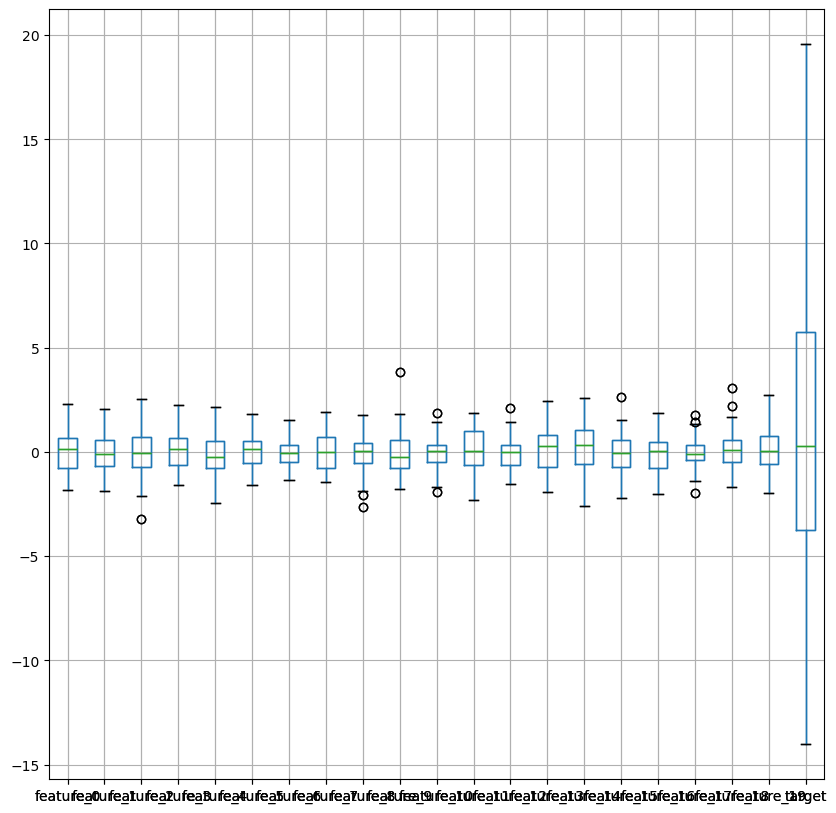

In [5]:
#plot

df.boxplot(figsize=(10,10))

df.boxplot()
plt.show()



In [11]:
#split data into tain and test, calculate y pred and calculate r2 score and mse
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

X=df.drop('target',axis=1)
y=df['target']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
model=LinearRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

In [12]:
#calculate ridge regression for train and test score

from sklearn.linear_model import Ridge
ridge_model=Ridge(alpha=1.0)
ridge_model.fit(X_train,y_train)
ridge_train_score=ridge_model.score(X_train,y_train)
ridge_test_score=ridge_model.score(X_test,y_test)
print("Train Score - ",ridge_train_score)
print("Test Score - ",ridge_test_score)

Train Score -  0.9681257749341244
Test Score -  0.7316351590907734


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso

# features and target
X = df.drop("target", axis=1)   # replace "target" with your target column
y = df["target"]

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

print("Ridge Training Score:", ridge.score(X_train, y_train))
print("Ridge Testing Score:", ridge.score(X_test, y_test))

# Lasso
lasso = Lasso(alpha=1.0)
lasso.fit(X_train, y_train)

print("Lasso Training Score:", lasso.score(X_train, y_train))
print("Lasso Testing Score:", lasso.score(X_test, y_test))


Ridge Training Score: 0.9681257749341244
Ridge Testing Score: 0.7316351590907734
Lasso Training Score: 0.8745787454389846
Lasso Testing Score: 0.7301485163474073


In [16]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, Lasso

# replace target with your actual target column
X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Ridge tuning
ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge())
])

ridge_params = {
    "model__alpha": [0.01, 0.1, 1, 10, 50, 100]
}

ridge_grid = GridSearchCV(ridge_pipeline, ridge_params, cv=5, scoring="r2")
ridge_grid.fit(X_train, y_train)

best_ridge = ridge_grid.best_estimator_

ridge_train_score = best_ridge.score(X_train, y_train)
ridge_test_score = best_ridge.score(X_test, y_test)

print("Best Ridge alpha:", ridge_grid.best_params_)
print("Ridge Train Score:", ridge_train_score)
print("Ridge Test Score:", ridge_test_score)




Best Ridge alpha: {'model__alpha': 10}
Ridge Train Score: 0.9426181246941123
Ridge Test Score: 0.5547806582736652


In [25]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

# replace "target" with your actual target column
X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.8, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

lasso = Lasso(alpha=0.01, max_iter=10000)
lasso.fit(X_train, y_train)

train_score = lasso.score(X_train, y_train)
test_score = lasso.score(X_test, y_test)

print("Training Score:", train_score)
print("Testing Score:", test_score)


Training Score: 0.9999308858039835
Testing Score: -0.4316095370482109


In [34]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# replace "target" with your actual target column
X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=20
)

models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.001, max_iter=50000)
}

for name, model in models.items():
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])
    
    pipeline.fit(X_train, y_train)
    
    train_score = pipeline.score(X_train, y_train)
    test_score = pipeline.score(X_test, y_test)
    
    print(name)
    print("Training R2 Score:", train_score)
    print("Testing R2 Score:", test_score)
    print()


Linear Regression
Training R2 Score: 0.9641159301528635
Testing R2 Score: 0.9370927630141055

Ridge
Training R2 Score: 0.9524578842114024
Testing R2 Score: 0.9240222767806542

Lasso
Training R2 Score: 0.9640693520078284
Testing R2 Score: 0.9420755872422792

